In [35]:
from __future__ import annotations
import uuid

import math
import random
from pathlib import Path
from tqdm import tqdm

import cv2
import numpy as np

import matplotlib.pyplot as plt

# Utilities

## Noise utils

In [99]:
def fade(t: np.ndarray) -> np.ndarray:
    return 6 * t**5 - 15 * t**4 + 10 * t**3


def lerp(a: np.ndarray, b: np.ndarray, t: np.ndarray) -> np.ndarray:
    return a + t * (b - a)


def generate_value_noise_2d(
    height: int,
    width: int,
    scale: float,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Generate smooth 2D value noise.
    """
    gh = int(np.ceil(height / scale)) + 2
    gw = int(np.ceil(width / scale)) + 2
    grid = rng.random((gh, gw), dtype=np.float32)

    y_coords = np.arange(height, dtype=np.float32) / scale
    x_coords = np.arange(width, dtype=np.float32) / scale
    yy, xx = np.meshgrid(y_coords, x_coords, indexing="ij")

    x0 = np.floor(xx).astype(np.int32)
    y0 = np.floor(yy).astype(np.int32)
    x1 = x0 + 1
    y1 = y0 + 1

    sx = fade(xx - x0)
    sy = fade(yy - y0)

    v00 = grid[y0, x0]
    v10 = grid[y0, x1]
    v01 = grid[y1, x0]
    v11 = grid[y1, x1]

    ix0 = lerp(v00, v10, sx)
    ix1 = lerp(v01, v11, sx)
    out = lerp(ix0, ix1, sy)

    return out


def fractal_noise_2d(
    height: int,
    width: int,
    base_scale: float,
    octaves: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Multi-octave smooth noise.
    """
    out = np.zeros((height, width), dtype=np.float32)
    amplitude = 1.0
    total_amplitude = 0.0
    scale = base_scale

    for _ in range(octaves):
        out += amplitude * generate_value_noise_2d(
            height, width, scale, rng
        )
        total_amplitude += amplitude
        amplitude *= 0.5
        scale /= 2.0

    out /= total_amplitude
    out -= out.min()
    out /= (out.max() + 1e-8)
    return out


def make_background(
    height: int,
    width: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Make a multicolour Perlin-like background in BGR for OpenCV.
    """
    n1 = fractal_noise_2d(height, width, BG_SCALE_1, BG_OCTAVES, rng)
    n2 = fractal_noise_2d(height, width, BG_SCALE_2, BG_OCTAVES, rng)
    n3 = fractal_noise_2d(height, width, BG_SCALE_1 * 1.35, BG_OCTAVES, rng)

    b = (255 * (0.60 * n1 + 0.40 * n2)).clip(0, 255).astype(np.uint8)
    g = (255 * (0.35 * n2 + 0.65 * n3)).clip(0, 255).astype(np.uint8)
    r = (255 * (0.55 * (1.0 - n1) + 0.45 * n3)).clip(0, 255).astype(np.uint8)

    bg = np.dstack([b, g, r])
    bg = cv2.GaussianBlur(bg, (0, 0), sigmaX=2.0, sigmaY=2.0)
    return bg

## Color utils

In [68]:
def distinct_bgr_colours(n: int) -> np.ndarray:
    """
    Generate visually distinct colours by spacing hues evenly in HSV space.
    Returns uint8 array of shape (n, 3) in BGR order.
    """
    hues = np.linspace(0, 179, n, endpoint=False).astype(np.uint8)
    sats = np.full(n, 220, dtype=np.uint8)
    vals = np.full(n, 255, dtype=np.uint8)

    hsv = np.stack([hues, sats, vals], axis=1).reshape(n, 1, 3)
    bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR).reshape(n, 3)
    return bgr

def constant_bgr_colours(n: int, color_hex: str) -> np.ndarray:
    """
    Generate a constant colour for n individuals from a hex string.
    Returns uint8 array of shape (n, 3) in BGR order.
    """
    # Remove '#' if present
    color_hex = color_hex.lstrip('#')
    # Convert hex to RGB
    r = int(color_hex[0:2], 16)
    g = int(color_hex[2:4], 16)
    b = int(color_hex[4:6], 16)

    # OpenCV uses BGR order
    bgr_color = [b, g, r]
    bgr = np.full((n, 3), bgr_color, dtype=np.uint8)
    return bgr

## Movement utils

In [69]:
def wrap_angle_pi(angle: np.ndarray) -> np.ndarray:
    return (angle + np.pi) % (2 * np.pi) - np.pi


def reflect_positions_and_headings(
    pos: np.ndarray,
    heading: np.ndarray,
    width: int,
    height: int,
    radius: float,
) -> None:
    """
    Reflect positions and headings in-place at square boundaries.
    """
    left = pos[:, 0] < radius
    if np.any(left):
        pos[left, 0] = 2 * radius - pos[left, 0]
        heading[left] = np.pi - heading[left]

    right = pos[:, 0] > (width - radius)
    if np.any(right):
        pos[right, 0] = 2 * (width - radius) - pos[right, 0]
        heading[right] = np.pi - heading[right]

    top = pos[:, 1] < radius
    if np.any(top):
        pos[top, 1] = 2 * radius - pos[top, 1]
        heading[top] = -heading[top]

    bottom = pos[:, 1] > (height - radius)
    if np.any(bottom):
        pos[bottom, 1] = 2 * (height - radius) - pos[bottom, 1]
        heading[bottom] = -heading[bottom]

    heading[:] = wrap_angle_pi(heading)


# Main function

In [102]:
def main() -> None:
    rng = np.random.default_rng(SEED)

    background = make_background(HEIGHT, WIDTH, rng)
    if USE_DISTINCT_COLORS:
        colours = distinct_bgr_colours(N_INDIVIDUALS)
    else:
        colours = constant_bgr_colours(N_INDIVIDUALS, COLOR)

    # Initial state
    pos = rng.uniform(
        low=[RADIUS, RADIUS],
        high=[WIDTH - RADIUS, HEIGHT - RADIUS],
        size=(N_INDIVIDUALS, 2),
    ).astype(np.float32)

    heading = rng.uniform(-np.pi, np.pi, size=N_INDIVIDUALS).astype(np.float32)
    slow_heading = heading.copy()

    base_speed = rng.uniform(
        BASE_SPEED_RANGE[0],
        BASE_SPEED_RANGE[1],
        size=N_INDIVIDUALS,
    ).astype(np.float32)
    speed = base_speed.copy()

    # Trajectory storage
    traj_rows: list[str] = ["id,frame,time_sec,x,y"]

    # Video writer
    out_path = Path(OUTPUT_VIDEO)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(out_path), fourcc, FPS, (WIDTH, HEIGHT))

    if not writer.isOpened():
        raise RuntimeError(
            "Could not open VideoWriter. Try a different codec."
        )

    # Initialize noise buffer for temporal persistence
    noise_buffer = None

    for frame_idx in tqdm(range(N_FRAMES)):
        # --- Movement Logic ---
        slow_heading += rng.normal(loc=0.0, scale=SLOW_TURN_STD, size=N_INDIVIDUALS).astype(np.float32)
        heading += (
            SLOW_HEADING_REVERSION * wrap_angle_pi(slow_heading - heading)
            + rng.normal(loc=0.0, scale=FAST_TURN_STD, size=N_INDIVIDUALS).astype(np.float32)
        )
        heading = wrap_angle_pi(heading)

        speed += (
            SPEED_REVERSION * (base_speed - speed)
            + rng.normal(loc=0.0, scale=SPEED_NOISE_STD, size=N_INDIVIDUALS).astype(np.float32)
        )
        speed = np.clip(speed, 0.2, None)

        step = np.column_stack((np.cos(heading), np.sin(heading))) * speed[:, None]
        pos += step.astype(np.float32)
        reflect_positions_and_headings(pos, heading, WIDTH, HEIGHT, RADIUS)

        # --- Data Saving ---
        time_sec = frame_idx / FPS
        for i in range(N_INDIVIDUALS):
            traj_rows.append(f"{i},{frame_idx},{time_sec:.6f},{pos[i, 0]:.6f},{pos[i, 1]:.6f}")

        # --- Drawing ---
        frame = background.copy()
        for i in range(N_INDIVIDUALS):
            center = tuple(np.round(pos[i]).astype(int))
            colour = tuple(int(c) for c in colours[i])
            cv2.circle(frame, center, RADIUS, colour, thickness=-1, lineType=cv2.LINE_AA)

            tip = (
                int(round(pos[i, 0] + 1.8 * RADIUS * math.cos(float(heading[i])))),
                int(round(pos[i, 1] + 1.8 * RADIUS * math.sin(float(heading[i])))),
            )
            cv2.line(frame, center, tip, (0, 0, 0), 1, lineType=cv2.LINE_AA)

        if DRAW_TIME_TEXT:
          cv2.putText(frame, f"t = {time_sec:5.1f} s", (15, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2, cv2.LINE_AA)

        # --- Temporal Noise Logic ---
        if ADD_NOISE:
            new_noise_sample = fractal_noise_2d(
                HEIGHT, WIDTH, NOISE_SCALE, NOISE_OCTAVES, rng
            )

            if noise_buffer is None:
                noise_buffer = new_noise_sample
            else:
                # noise = (1-alpha)*old + alpha*new
                noise_buffer = (1.0 - NOISE_ALPHA) * noise_buffer + NOISE_ALPHA * new_noise_sample

            scaled_noise = (noise_buffer - 0.5) * 2 * 255 * NOISE_AMPLITUDE
            frame = frame.astype(np.float32) + scaled_noise[:, :, np.newaxis]
            frame = np.clip(frame, 0, 255).astype(np.uint8)

        writer.write(frame)

    writer.release()
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.show()

    Path(OUTPUT_CSV).write_text("\n".join(traj_rows), encoding="utf-8")
    print(f"Saved video to: {OUTPUT_VIDEO}")

# Execute

In [119]:
WIDTH = 900
HEIGHT = 900

N_INDIVIDUALS = 12
FPS = 30
DURATION_S = 60
N_FRAMES = FPS * DURATION_S

id_ = "with_noise_1"
SEED = random.randint(1, 1001)
RADIUS = 10

OUTPUT_VIDEO = f"{id_}.mp4"
OUTPUT_CSV = f"{id_}.csv"

# Movement parameters
BASE_SPEED_RANGE = (1.0, 3.5)
SLOW_TURN_STD = 0.015
FAST_TURN_STD = 0.08
SLOW_HEADING_REVERSION = 0.01
SPEED_NOISE_STD = 0.08
SPEED_REVERSION = 0.03

# Background parameters
BG_SCALE_1 = 150.0
BG_SCALE_2 = 40.0
BG_OCTAVES = 4

# Individual color
USE_DISTINCT_COLORS = False
COLOR = "#1c5ab2"

# Display
DRAW_TIME_TEXT = False

# Time-varying noise parameters (Temporal Smoothing)
ADD_NOISE = True
NOISE_SCALE = 100.0
NOISE_OCTAVES = 3
NOISE_AMPLITUDE = 0.4
# NOISE_ALPHA: 0.0 to 1.0. Lower values = more persistence/slower change.
NOISE_ALPHA = 0.05

100%|██████████| 1800/1800 [21:16<00:00,  1.41it/s]


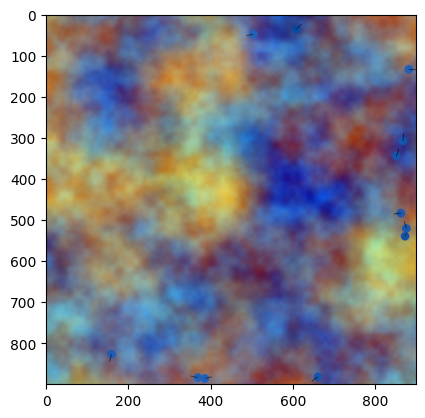

Saved video to: with_noise_1.mp4


In [120]:
main()

# Convert movie

In [121]:
ffmpeg_command = f'ffmpeg -y -i "{OUTPUT_VIDEO}" -c:v libx264 -an "{OUTPUT_VIDEO}_converted.mp4"'
get_ipython().system(ffmpeg_command)


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab